# 01 – Exploratory Data Analysis: Credit Card Fraud Detection

**Projekt:** `autoencoder-fraud-detection`

**Mål:** Bygga en Autoencoder som lär sig hur legitima transaktioner ser ut, och som därmed kan flagga bedrägliga transaktioner genom att de får ett högt rekonstruktionsfel (modellen "känner inte igen" dem).

**Dataset:** Kaggle *"Credit Card Fraud Detection"* (`mlg-ulb/creditcardfraud`)
- 284 807 transaktioner, varav 492 är bedrägerier (~0,17 %)
- 28 PCA-transformerade features (`V1`–`V28`), samt `Time`, `Amount` och `Class` (otransformerade)
- `Class`: 0 = legitim, 1 = bedrägeri

**Den här notebooken:** laddar in datasetet, kontrollerar datakvalitet, utforskar klassobalans och variablernas fördelning, och sparar figurer/rapporter som vi återanvänder i presentationen senare.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# Skapa output-mappar om de inte redan finns
os.makedirs('../reports/figures', exist_ok=True)

RANDOM_STATE = 42


## Ladda in dataset

Vi läser in `creditcard.csv` och tittar på grundläggande struktur: antal rader/kolumner, datatyper och de första raderna.

In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')

print(f"Antal rader: {df.shape[0]}")
print(f"Antal kolumner: {df.shape[1]}")
print()
df.info()


Antal rader: 284807
Antal kolumner: 31

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-

In [3]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Vad ser vi?**

Datasetet har 284 807 rader och 31 kolumner, precis som väntat. Alla kolumner är fullständigt ifyllda (284 807 non-null överallt) — inga NaN på kolumnnivå enligt `.info()`. `Time`, `V1`–`V28` och `Amount` är `float64`, `Class` är `int64` (0/1). Minnesanvändning ~67 MB, hanterbart utan särskild optimering. `V1`–`V28` ser ut att vara centrerade kring 0 (PCA-transformerade), medan `Time` och `Amount` är i sina ursprungliga skalor — de kommer behöva standardiseras innan träning (samma mönster som i kursexemplet).

## Saknade värden och dubbletter

Innan vi går vidare kontrollerar vi grundläggande datakvalitet: saknade värden och dubblettrader.

In [4]:
print("Saknade värden totalt:", df.isnull().sum().sum())
print("Antal dubblettrader:", df.duplicated().sum())


Saknade värden totalt: 0
Antal dubblettrader: 1081


**Vad ser vi?**

Inga saknade värden alls (`0` totalt) — bra, ingen imputering behövs. Däremot hittar vi **1081 dubblettrader** (~0,4 % av datasetet). Det är tillräckligt många för att påverka resultatet om de hamnar på båda sidor av en train/test-split (data leakage — modellen skulle då "sett" en identisk rad redan under träning). **Beslut:** vi tar bort dubbletter i nästa notebook, innan vi delar upp datasetet i tränings- och testset.

## Klassfördelning – legitima vs bedrägliga transaktioner

Det här är den centrala egenskapen hos datasetet och anledningen till att vi väljer en Autoencoder-ansats: klasserna är extremt obalanserade, så vi tränar modellen enbart på legitima transaktioner och låter den flagga det som avviker.

Antal per klass:
Class
0    284315
1       492
Name: count, dtype: int64

Andel per klass (%):
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


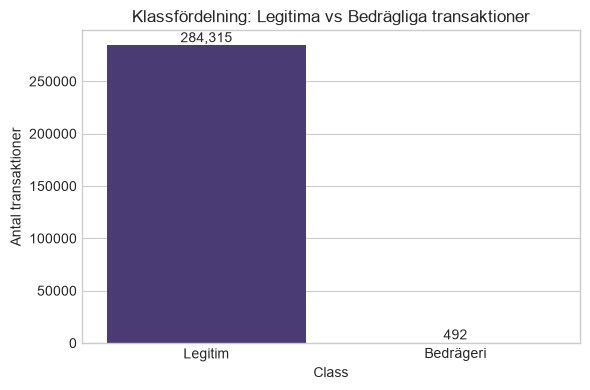

In [5]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print("Antal per klass:")
print(class_counts)
print()
print("Andel per klass (%):")
print(class_pct.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
labels = class_counts.index.map({0: 'Legitim', 1: 'Bedrägeri'})
sns.barplot(x=labels, y=class_counts.values, ax=ax)
ax.set_title('Klassfördelning: Legitima vs Bedrägliga transaktioner')
ax.set_ylabel('Antal transaktioner')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 3000, f"{v:,}", ha='center')
plt.tight_layout()
plt.savefig('../reports/figures/01_class_distribution.png', dpi=150)
plt.show()

# Spara sammanfattning till rapport (återanvänds i presentationen)
class_summary = pd.DataFrame({'count': class_counts, 'percentage': class_pct.round(4)})
class_summary.to_csv('../reports/class_distribution.csv')


**Vad ser vi?**

Extrem klassobalans: 284 315 legitima transaktioner (99,83 %) mot bara 492 bedrägerier (0,1727 %). Det bekräftar varför en vanlig klassificerare skulle ha svårt att lära sig mönstret för minoritetsklassen — och varför Autoencoder-ansatsen passar bra: vi tränar bara på den stora, homogena "legitim"-klassen och låter modellen flagga det som avviker, istället för att försöka lära en klass med bara ~500 exempel.

## Fördelning av `Time` och `Amount`

`Time` och `Amount` är de enda features som inte är PCA-transformerade. Vi tittar på deras fördelningar innan skalning.

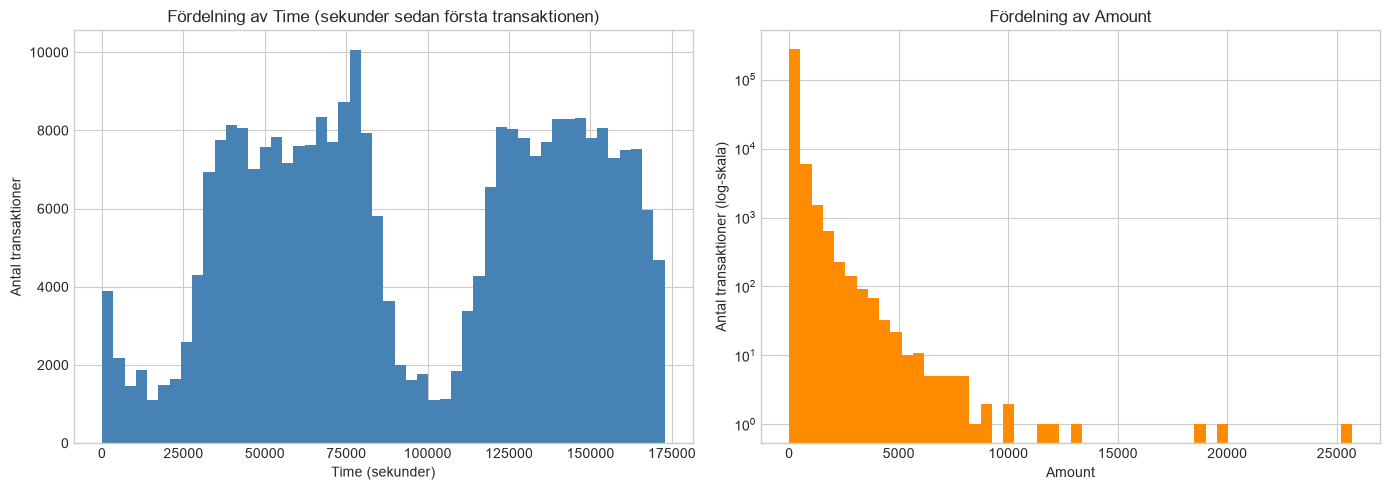

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Time'], bins=50, color='steelblue')
axes[0].set_title('Fördelning av Time (sekunder sedan första transaktionen)')
axes[0].set_xlabel('Time (sekunder)')
axes[0].set_ylabel('Antal transaktioner')

axes[1].hist(df['Amount'], bins=50, color='darkorange')
axes[1].set_title('Fördelning av Amount')
axes[1].set_xlabel('Amount')
axes[1].set_yscale('log')
axes[1].set_ylabel('Antal transaktioner (log-skala)')

plt.tight_layout()
plt.savefig('../reports/figures/02_time_amount_distribution.png', dpi=150)
plt.show()


**Vad ser vi?**

`Time` (sekunder sedan första transaktionen, ~172 792 sekunder ≈ 48 timmar totalt) visar ett tydligt tvåpucklat mönster med två dalar — det matchar två nätter av lägre transaktionsvolym följt av dagtid med hög aktivitet. Det bekräftar att datasetet spänner över ungefär två dygn.

`Amount` är kraftigt högerskevt: de allra flesta transaktioner är små belopp, medan ett fåtal sträcker sig upp mot 25 691 — därför behövs logskala för att kunna se fördelningen alls. Det är en av anledningarna till att `Amount` (tillsammans med `Time`) behöver skalas separat innan träning, till skillnad från `V1`–`V28` som redan är PCA-transformerade.

## Amount per klass

Vi jämför `Amount` mellan legitima och bedrägliga transaktioner – om bedrägerier tenderar att ha andra beloppsmönster är det bra att känna till innan vi tränar modellen.

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


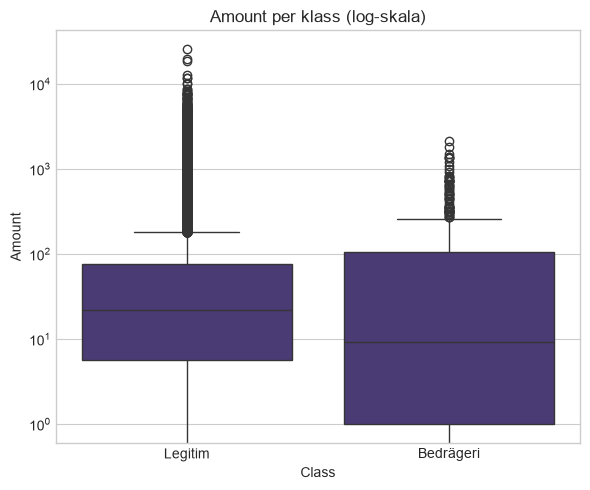

In [7]:
amount_by_class = df.groupby('Class')['Amount'].describe()
print(amount_by_class)
amount_by_class.to_csv('../reports/amount_by_class_summary.csv')

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(x='Class', y='Amount', data=df, ax=ax)
ax.set_yscale('log')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Legitim', 'Bedrägeri'])
ax.set_title('Amount per klass (log-skala)')
plt.tight_layout()
plt.savefig('../reports/figures/03_amount_by_class_boxplot.png', dpi=150)
plt.show()


**Vad ser vi?**

Bedrägliga transaktioner har högre medelbelopp (122,21 mot 88,29) men lägre medianbelopp (9,25 mot 22,00) än legitima — det tyder på att bedrägerier ofta är små "testbelopp" men med en svans av enstaka större belopp som drar upp medelvärdet. Notera också att maxbeloppet för bedrägeri (2 125,87) är mycket lägre än för legitima transaktioner (25 691,16) — bedragare verkar undvika riktigt stora belopp, sannolikt för att inte trigga andra säkerhetskontroller. Den bredare spridningen (kvartiler 1,00–105,89 mot 5,65–77,05 för legitima) visar att `Amount` inte ensamt räcker för att skilja klasserna åt, men är ändå ett relevant signal-feature.

## Korrelation mellan features och `Class`

`V1`–`V28` är redan PCA-transformerade och därmed inbördes okorrelerade, men vi kan ändå titta på vilka som korrelerar mest (positivt/negativt) med `Class`. Det ger en känsla för vilka mönster autoencodern behöver kunna återskapa väl för legitima transaktioner.

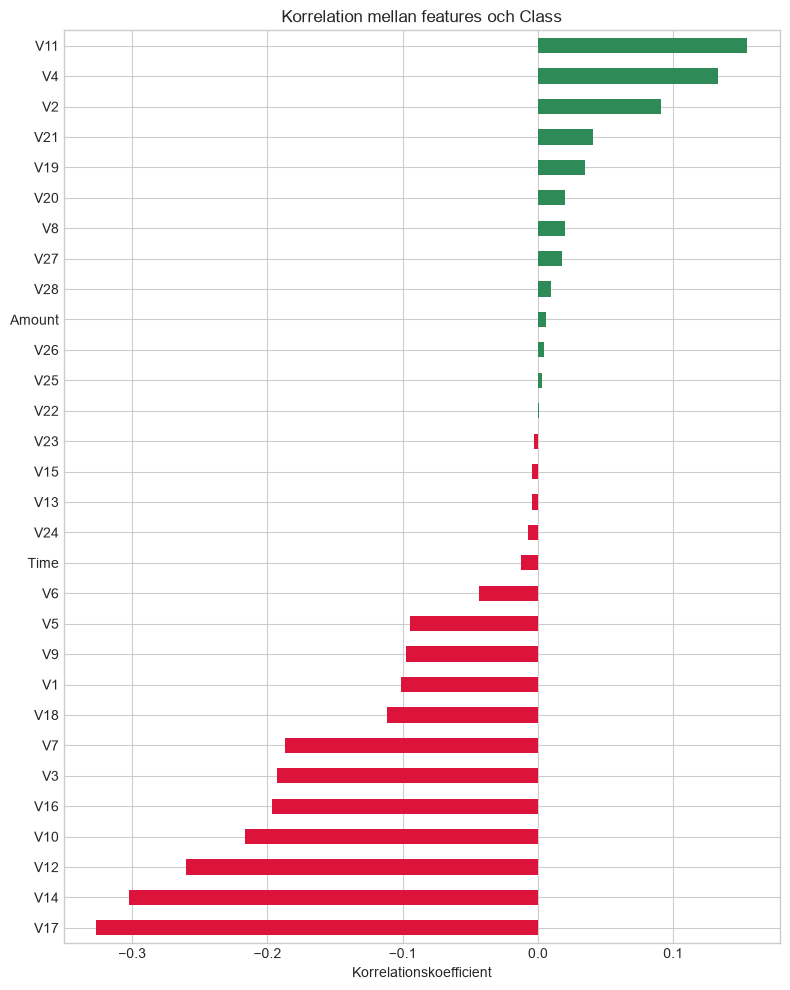

In [8]:
correlations = df.corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
colors = correlations.apply(lambda x: 'crimson' if x < 0 else 'seagreen')
correlations.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Korrelation mellan features och Class')
ax.set_xlabel('Korrelationskoefficient')
plt.tight_layout()
plt.savefig('../reports/figures/04_feature_correlation_with_class.png', dpi=150)
plt.show()

correlations.to_csv('../reports/feature_correlation_with_class.csv', header=['correlation'])


**Vad ser vi?**

Starkast negativt korrelerade med `Class` (dvs. låga värden på dessa komponenter förknippas med bedrägeri) är `V17` (~-0,33), `V14` (~-0,30), `V12` (~-0,26) och `V10` (~-0,22). Starkast positivt korrelerade är `V11` (~0,15), `V4` (~0,13) och `V2` (~0,09). `Time` och `Amount` har båda mycket svag korrelation med `Class` på egen hand — det bekräftar att bedrägeri inte kan förklaras av ett enda feature, utan är ett mönster spritt över flera av de PCA-transformerade komponenterna. Det stämmer väl överens med kända resultat för det här datasetet och stärker valet av en modell (Autoencoder) som kan fånga samspelet mellan många features samtidigt.

## Sammanfattning av EDA

- **Datakvalitet:** Inga saknade värden, men **1081 dubblettrader** hittades — dessa tas bort innan train/test-split i nästa steg.
- **Extrem klassobalans:** 99,83 % legitima vs 0,17 % bedrägerier — motiverar Autoencoder-ansatsen (träna endast på legitima transaktioner, flagga avvikelser via rekonstruktionsfel).
- **Skalning behövs:** `Time` och `Amount` är i sina ursprungliga skalor och skiljer sig kraftigt från de redan PCA-transformerade `V1`–`V28`. Båda behöver standardiseras (`StandardScaler`) innan träning.
- **`Amount`-mönster:** Bedrägerier tenderar mot antingen mycket små belopp eller måttliga belopp, sällan riktigt stora — ett svagt men relevant signal-feature.
- **Starkaste feature-korrelationer med `Class`:** `V17`, `V14`, `V12`, `V10` (negativt) och `V11`, `V4`, `V2` (positivt) — inget enskilt feature dominerar, vilket stödjer en modell som kan väga samman flera dimensioner.

**Nästa steg:** `02_autoencoder_model.ipynb` — ta bort dubbletter, skala `Time`/`Amount`, träna autoencoder på enbart legitima transaktioner, och bestäm tröskel för anomali-flaggning från validation-setet.